In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import treedata as td
import scanpy as sc

NOTE : The following analysis and data was generated and done without the trees "E8.5-R3-C1", "E8.5-R2-C1", "E8.5-R2-C2". 

In [ ]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/Trees/Robin_Pijuan_celltypist/Manual_Cardiac_Annotation/E8_5/"
output_path_plot = base_path+plot_dir+"/Trees/Robin_Pijuan_celltypist/Manual_Cardiac_Annotation/E8_5/"


In [9]:
adata = td.read_h5td(base_path+'output_data/Processed_data/E8_5.h5td')

In [4]:
# ---- Load the three outputs ----
df_leaf_depth = pd.read_csv(output_path_data + "leaf_depth_all_trees.csv")
df_resolution = pd.read_csv(output_path_data + "resolution_all_trees.csv")
df_permutation = pd.read_csv(output_path_data + "permutation_all_trees.csv")

In [5]:
# add replicate column (adjust split logic to your actual naming, e.g. "E8.5-R3-C1" -> "R3")
for df in [df_leaf_depth, df_resolution, df_permutation]:
    df["replicate"] = df["tree"].str.extract(r'-(R\d+)-')
    print(df)

            tree           cell_type  depth  depth_norm  n_leaves replicate
0     E8.5-R1-C1                pSHF     12    0.750000      6192        R1
1     E8.5-R1-C1                pSHF     10    0.625000      6192        R1
2     E8.5-R1-C1                pSHF      9    0.562500      6192        R1
3     E8.5-R1-C1                pSHF      9    0.562500      6192        R1
4     E8.5-R1-C1                aSHF     11    0.687500      6192        R1
...          ...                 ...    ...         ...       ...       ...
1698  E8.5-R3-C3  Differentiating CM      7    0.538462       664        R3
1699  E8.5-R3-C3  Differentiating CM      7    0.538462       664        R3
1700  E8.5-R3-C3                aSHF      7    0.538462       664        R3
1701  E8.5-R3-C3                aSHF      7    0.538462       664        R3
1702  E8.5-R3-C3  Differentiating CM      6    0.461538       664        R3

[1703 rows x 6 columns]
         tree  n_leaves  n_polytomies  n_internal_nodes  polyto

1. CELLTYPE ~ DEPTH MIXED-EFFECTS MODEL


/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       depth_norm
No. Observations:       1703          Method:                   REML      
No. Groups:             6             Scale:                    0.0109    
Min. group size:        23            Log-Likelihood:           1402.7126 
Max. group size:        553           Converged:                Yes       
Mean group size:        283.8                                             
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        0.610    0.016 37.748 0.000  0.578  0.642
cell_type[T.Differentiating CM]  0.014    0.008  1.758 0.079 -0.002  0.029
cell_type[T.JCF]                -0.026    0.010 -2.526 0.012 -0.046 -0.006
cell_type[T.aSHF]                0.039    0.

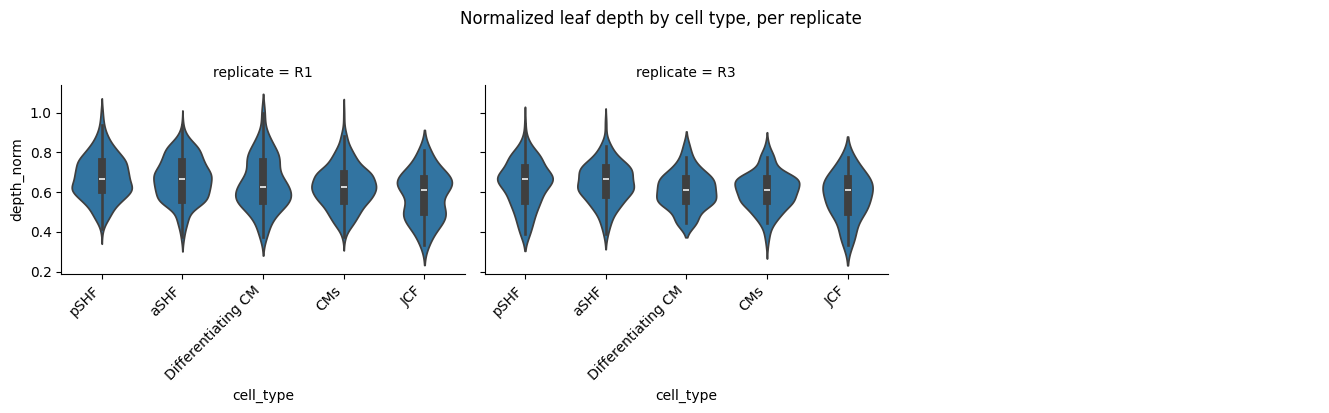

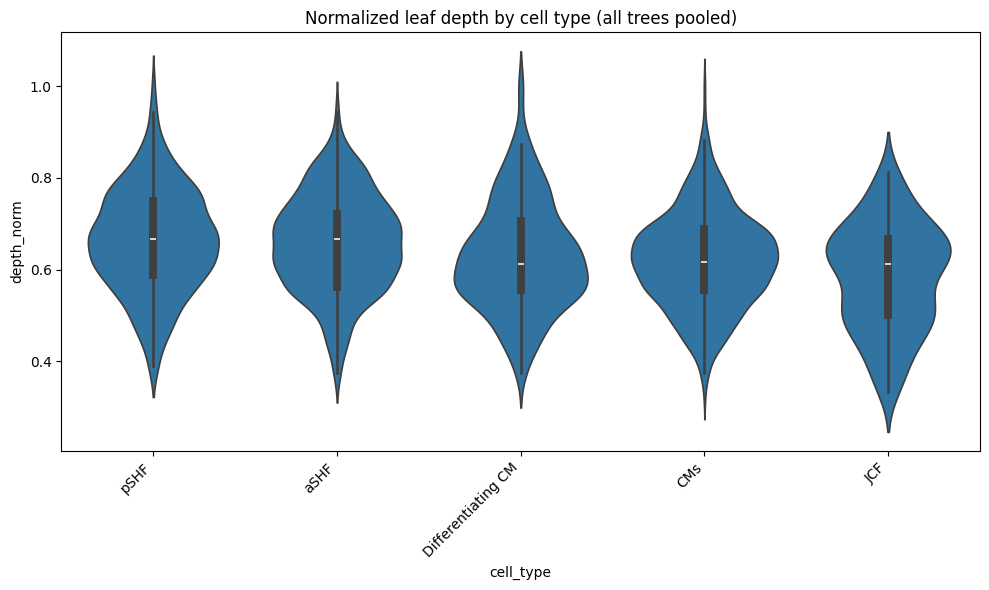

In [6]:


# =========================================================
# 1. Celltype ~ depth (mixed-effects model)
# =========================================================
print("=" * 60)
print("1. CELLTYPE ~ DEPTH MIXED-EFFECTS MODEL")
print("=" * 60)

model = smf.mixedlm("depth_norm ~ cell_type", data=df_leaf_depth, groups=df_leaf_depth["tree"])
result = model.fit()
print(result.summary())

# visualize: depth distribution by cell type, faceted by replicate
g = sns.catplot(
    data=df_leaf_depth, x="cell_type", y="depth_norm",
    col="replicate", kind="violin", col_wrap=3, height=4, aspect=1.1
)
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle("Normalized leaf depth by cell type, per replicate", y=1.02)
plt.tight_layout()
plt.savefig(output_path_plot + "depth_by_celltype_replicate.svg", bbox_inches='tight')
plt.show()

# also pooled across all replicates
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_leaf_depth, x="cell_type", y="depth_norm")
plt.xticks(rotation=45, ha='right')
plt.title("Normalized leaf depth by cell type (all trees pooled)")
plt.tight_layout()
plt.savefig(output_path_plot + "depth_by_celltype_pooled.svg", bbox_inches='tight')
plt.show()



There is a statistically significant different in depth between the CM and all the other celltype except differentiating CM, which makes sense because differentiating is simply too close. 

2a. FATE COUPLING MATRIX


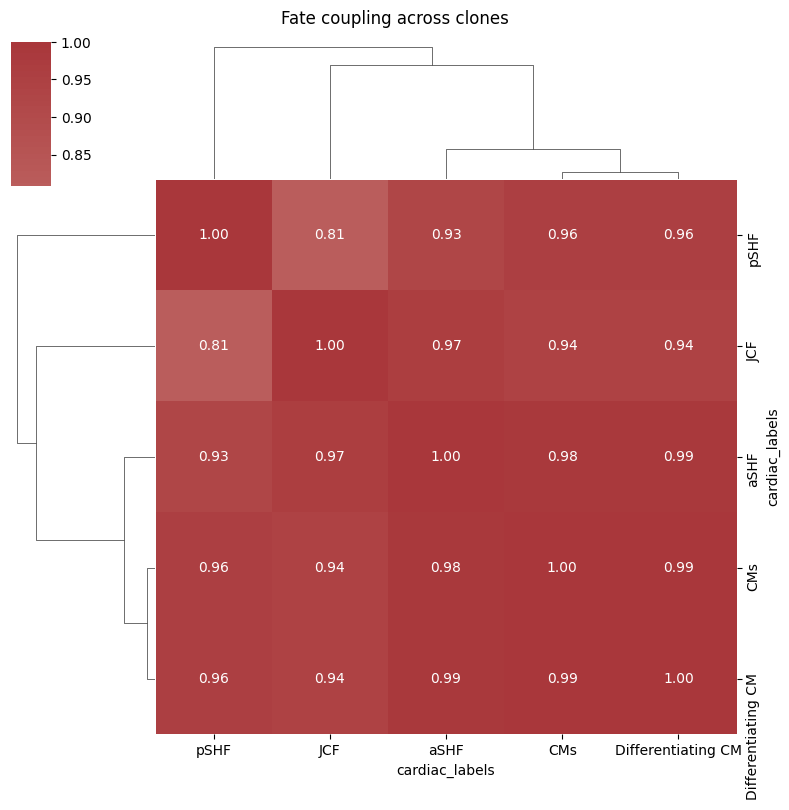


Fate coupling matrix:
cardiac_labels       CMs  Differentiating CM   JCF  aSHF  pSHF
cardiac_labels                                                
CMs                 1.00                0.99  0.94  0.98  0.96
Differentiating CM  0.99                1.00  0.94  0.99  0.96
JCF                 0.94                0.94  1.00  0.97  0.81
aSHF                0.98                0.99  0.97  1.00  0.93
pSHF                0.96                0.96  0.81  0.93  1.00


In [10]:
# =========================================================
# 2a. Fate coupling matrix
# =========================================================
print("=" * 60)
print("2a. FATE COUPLING MATRIX")
print("=" * 60)

def compute_fate_coupling(adata, tree_key='tree', celltype_key='cardiac_labels', min_cells_per_tree=1):
    counts = pd.crosstab(adata.obs[tree_key], adata.obs[celltype_key])
    counts = counts[counts.sum(axis=1) >= min_cells_per_tree]
    coupling = counts.corr()
    return coupling, counts

coupling, ct_counts = compute_fate_coupling(adata, tree_key='tree', celltype_key='cardiac_labels')

g = sns.clustermap(coupling, cmap="vlag", center=0, annot=True, fmt=".2f", figsize=(8, 8))
g.fig.suptitle("Fate coupling across clones", y=1.02)
g.savefig(output_path_plot + "fate_coupling.svg", bbox_inches='tight')
plt.show()

print("\nFate coupling matrix:")
print(coupling.round(2))


Using proportion instead of raw celltype count

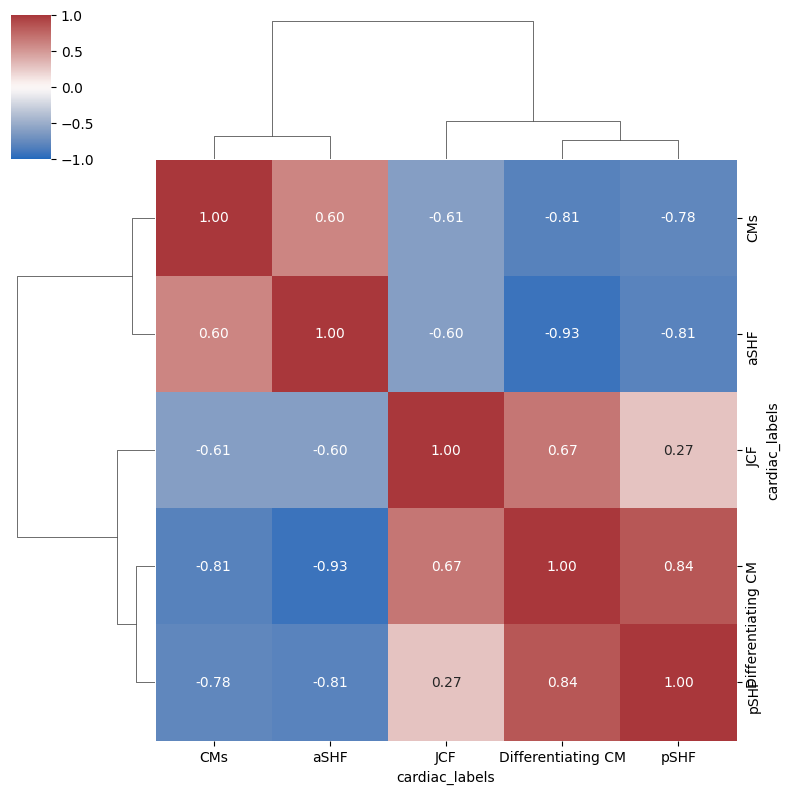

In [11]:
def compute_fate_coupling(adata, tree_key='tree', celltype_key='cardiac_labels', min_cells_per_tree=1):
    counts = pd.crosstab(adata.obs[tree_key], adata.obs[celltype_key])
    counts = counts[counts.sum(axis=1) >= min_cells_per_tree]
    proportions = counts.div(counts.sum(axis=1), axis=0)  # normalize per tree
    coupling = proportions.corr()
    return coupling, counts

coupling, ct_counts = compute_fate_coupling(adata, tree_key='tree', celltype_key='cardiac_labels')
g = sns.clustermap(coupling, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", figsize=(8, 8))

Seems to form two clusters. Clones with CMs and aSHF are more likely to be seen together than to other cell type. The same goes for the JCF, differentiating CM and pSHF clones. 

2b. PERMUTATION TEST SUMMARY (SAME-TYPE VS DIFF-TYPE CLUSTERING)
5/6 trees show significant fate clustering (p < 0.05)


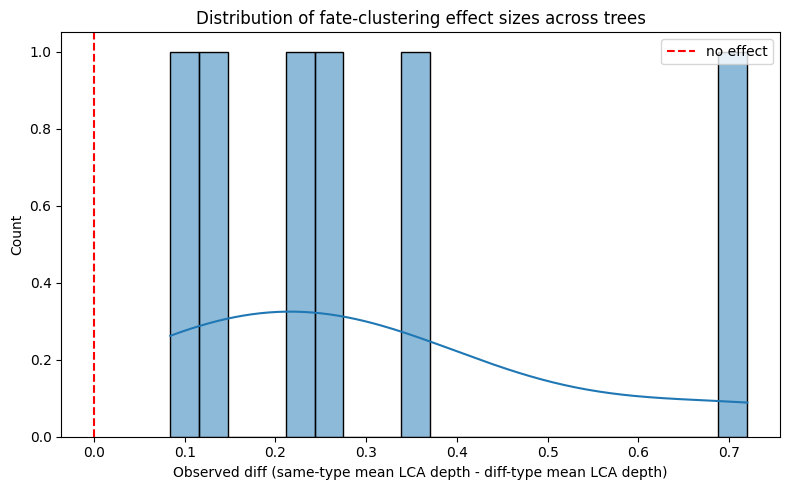

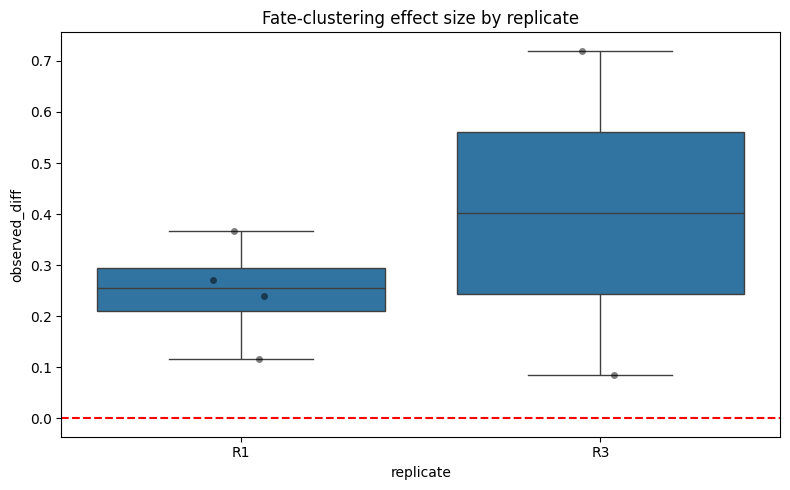


Top 10 trees by strongest clustering signal:
         tree  observed_diff   p_value
0  E8.5-R1-C1       0.116517  0.001996
1  E8.5-R1-C2       0.367028  0.001996
2  E8.5-R1-C3       0.240241  0.001996
4  E8.5-R3-C2       0.084220  0.001996
5  E8.5-R3-C3       0.719968  0.001996
3  E8.5-R1-C4       0.271350  0.053892

Trees with NO significant clustering (p >= alpha):
         tree  observed_diff   p_value
3  E8.5-R1-C4        0.27135  0.053892


In [12]:


# =========================================================
# 2b. Permutation test results (same-type vs diff-type LCA depth)
# =========================================================
print("=" * 60)
print("2b. PERMUTATION TEST SUMMARY (SAME-TYPE VS DIFF-TYPE CLUSTERING)")
print("=" * 60)

# how many trees show significant same-type clustering?
alpha = 0.05
n_sig = (df_permutation["p_value"] < alpha).sum()
n_total = len(df_permutation)
print(f"{n_sig}/{n_total} trees show significant fate clustering (p < {alpha})")

# effect size distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_permutation["observed_diff"], bins=20, kde=True)
plt.axvline(0, color='red', linestyle='--', label='no effect')
plt.xlabel("Observed diff (same-type mean LCA depth - diff-type mean LCA depth)")
plt.title("Distribution of fate-clustering effect sizes across trees")
plt.legend()
plt.tight_layout()
plt.savefig(output_path_plot + "permutation_effect_sizes.svg", bbox_inches='tight')
plt.show()

# by replicate
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_permutation, x="replicate", y="observed_diff")
sns.stripplot(data=df_permutation, x="replicate", y="observed_diff", color='black', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Fate-clustering effect size by replicate")
plt.tight_layout()
plt.savefig(output_path_plot + "permutation_effect_by_replicate.svg", bbox_inches='tight')
plt.show()

print("\nTop 10 trees by strongest clustering signal:")
print(df_permutation.sort_values("p_value").head(10)[["tree", "observed_diff", "p_value"]])

print("\nTrees with NO significant clustering (p >= alpha):")
print(df_permutation[df_permutation["p_value"] >= alpha][["tree", "observed_diff", "p_value"]])



Good to see that same fate cells are more closely related within trees than different-fate cells. Need to dig into why there might be such a big variability of the relation. Is it due to tree size? Replicate? Cell type diversity? Or something else?

3. TREE RESOLUTION (POLYTOMY) DIAGNOSTIC
         tree  n_leaves  n_polytomies  polytomy_fraction  \
0  E8.5-R1-C1      6192          1241           0.349972   
3  E8.5-R1-C4       429            89           0.339695   
4  E8.5-R3-C2      4202           852           0.335962   
1  E8.5-R1-C2      2256           431           0.319733   
2  E8.5-R1-C3      2955           544           0.293420   
5  E8.5-R3-C3       664           126           0.285068   

   mean_polytomy_depth_norm  
0                  0.575947  
3                  0.478825  
4                  0.529017  
1                  0.532869  
2                  0.544875  
5                  0.539072  


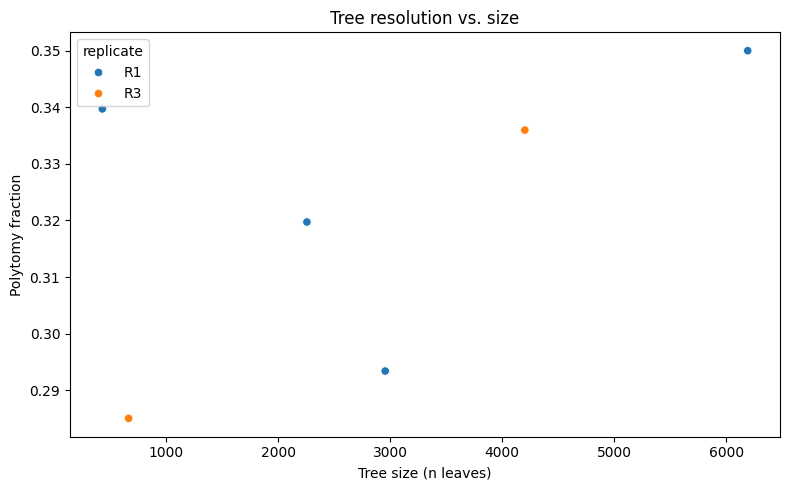


Trees flagged as low-confidence (polytomy fraction > 0.3):
['E8.5-R1-C1', 'E8.5-R1-C2', 'E8.5-R1-C4', 'E8.5-R3-C2']


In [13]:

# =========================================================
# 3. Tree resolution / confidence diagnostic
# =========================================================
print("=" * 60)
print("3. TREE RESOLUTION (POLYTOMY) DIAGNOSTIC")
print("=" * 60)

df_resolution_sorted = df_resolution.sort_values("polytomy_fraction", ascending=False)
print(df_resolution_sorted[["tree", "n_leaves", "n_polytomies", "polytomy_fraction", "mean_polytomy_depth_norm"]])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_resolution, x="n_leaves", y="polytomy_fraction", hue="replicate")
plt.xlabel("Tree size (n leaves)")
plt.ylabel("Polytomy fraction")
plt.title("Tree resolution vs. size")
plt.tight_layout()
plt.savefig(output_path_plot + "resolution_vs_size.svg", bbox_inches='tight')
plt.show()

# flag low-confidence trees — high polytomy fraction, especially concentrated near leaves
LOW_CONFIDENCE_THRESHOLD = 0.3  # tune based on your distribution above
low_confidence_trees = df_resolution[df_resolution["polytomy_fraction"] > LOW_CONFIDENCE_THRESHOLD]["tree"].tolist()
print(f"\nTrees flagged as low-confidence (polytomy fraction > {LOW_CONFIDENCE_THRESHOLD}):")
print(low_confidence_trees)


The fraction of unresolved internal split could be a little concerning, and seems to scale with the size of the tree. For now, I will continue with the same analysis for the other three trees. But other implementations like subsampling will be put in place to ensure the depth analysis robustness for the earlier tests

CROSS-CHECK: RESOLUTION VS PERMUTATION RESULTS


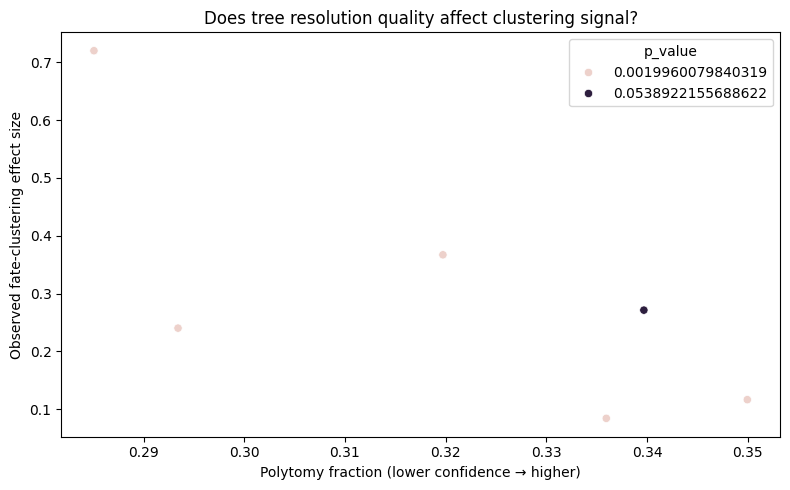


Correlation (polytomy_fraction vs observed_diff): -0.7453420057002005

Mixed-model results EXCLUDING low-confidence trees (robustness check):
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       depth_norm
No. Observations:       340           Method:                   REML      
No. Groups:             2             Scale:                    0.0104    
Min. group size:        56            Log-Likelihood:           278.8179  
Max. group size:        284           Converged:                Yes       
Mean group size:        170.0                                             
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        0.620    0.023 27.143 0.000  0.575  0.664
cell_type[T.Differentiating CM] -0.014    0.017 -0.

/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [14]:


# =========================================================
# Cross-check: does resolution quality affect the other analyses?
# =========================================================
print("=" * 60)
print("CROSS-CHECK: RESOLUTION VS PERMUTATION RESULTS")
print("=" * 60)

merged = df_permutation.merge(df_resolution[["tree", "polytomy_fraction", "n_leaves"]], on="tree")
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged, x="polytomy_fraction", y="observed_diff", hue="p_value" if "p_value" in merged else None)
plt.xlabel("Polytomy fraction (lower confidence \u2192 higher)")
plt.ylabel("Observed fate-clustering effect size")
plt.title("Does tree resolution quality affect clustering signal?")
plt.tight_layout()
plt.savefig(output_path_plot + "resolution_vs_clustering_signal.svg", bbox_inches='tight')
plt.show()

print("\nCorrelation (polytomy_fraction vs observed_diff):",
      merged["polytomy_fraction"].corr(merged["observed_diff"]))

# re-run the depth model excluding low-confidence trees, as a robustness check
df_leaf_depth_filtered = df_leaf_depth[~df_leaf_depth["tree"].isin(low_confidence_trees)]
model_filtered = smf.mixedlm("depth_norm ~ cell_type", data=df_leaf_depth_filtered,
                               groups=df_leaf_depth_filtered["tree"])
result_filtered = model_filtered.fit()
print("\nMixed-model results EXCLUDING low-confidence trees (robustness check):")
print(result_filtered.summary())

I see a strong negative correlation with the amount of unresolve internal nodes and how strongly same fate cells cluster with each other. I would suspect that if the internal nodes gets resolved, the same fate cluster would be even stronger then. But then again, all but one tree show a pretty significant difference even with such high uncertainties